# Inverse Problems: Recovering Hidden Physics from Noisy Data

> **Repository:** [PINNs-RL-PDE](https://github.com/josegarciav/PINNs-RL-PDE) &nbsp;|&nbsp; **Package:** `pinnrl` &nbsp;|&nbsp; **Estimated run time:** ~30 seconds on CPU

Most science starts with the *forward* problem: "given physics, predict the data." Inverse problems flip it around — given data, recover the physics. They are how:

- a materials engineer turns a thermal-imaging video into a thermal diffusivity estimate,
- a quant fits implied volatility from option prices,
- a hydrologist reconstructs subsurface permeability from well measurements,
- a doctor estimates blood-perfusion rates from MRI contrast.

Classical inverse-problem methods (adjoint optimization, ensemble Kalman filters) are mesh-bound and computationally expensive. PINNs handle them naturally: the unknown parameter is just one more thing the optimizer minimizes, alongside the network weights.

This notebook shows the full mechanic on the simplest non-trivial example: recovering the **thermal diffusivity** $\alpha$ of the heat equation from noisy temperature measurements.

## 1  The Setup

Heat equation on $x \in [0, 1]$, $t \in [0, 1]$:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad u(x, 0) = \sin(2\pi x), \quad u(0, t) = u(1, t) = 0$$

**Forward problem:** given $\alpha$, compute $u(x, t)$. Closed-form: $u(x, t) = \sin(2\pi x)\, e^{-\alpha (2\pi)^2 t}$.

**Inverse problem:** given $\{(x_i, t_i, u_i + \text{noise})\}_{i=1}^{N}$, recover $\alpha$.

We will pretend we don't know $\alpha$. The PINN will be told there is *some* $\alpha$ that satisfies the heat equation, the optimizer will tune both the network weights and $\alpha$ jointly, and we will check whether $\alpha$ converges to the true value buried in the data.

## 2  Setup & Imports

In [1]:
import sys, os, time

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

device = torch.device("cpu")
torch.manual_seed(0)
np.random.seed(0)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

PyTorch  : 2.10.0
Device   : cpu


## 3  Build the Ground-Truth World

We pick a true $\alpha$, generate the analytical solution on a random scatter of $(x, t)$ points, and add Gaussian noise to mimic a real sensor. The PINN will only ever see these noisy observations — never the value of $\alpha$ that produced them.

In [2]:
TRUE_ALPHA    = 0.05      # the value the PINN has to recover
INITIAL_GUESS = 0.50      # 10x off — give the optimizer a real distance to cover
X_MIN, X_MAX  = 0.0, 1.0
T_MIN, T_MAX  = 0.0, 1.0

def analytical_u(x, t, alpha):
    """Closed-form heat solution u(x,t) = sin(2 pi x) * exp(-alpha (2 pi)^2 t)."""
    k = 2.0 * np.pi
    return np.sin(k * x) * np.exp(-alpha * k * k * t)

# Synthetic noisy observations
N_OBS      = 200
NOISE_STD  = 0.005
rng        = np.random.default_rng(0)
x_obs_np   = rng.uniform(X_MIN, X_MAX, size=(N_OBS, 1)).astype(np.float32)
t_obs_np   = rng.uniform(T_MIN, T_MAX, size=(N_OBS, 1)).astype(np.float32)
u_clean    = analytical_u(x_obs_np, t_obs_np, TRUE_ALPHA)
u_obs_np   = u_clean + NOISE_STD * rng.standard_normal(u_clean.shape).astype(np.float32)

x_obs = torch.tensor(x_obs_np, device=device)
t_obs = torch.tensor(t_obs_np, device=device)
u_obs = torch.tensor(u_obs_np, device=device)

print(f"True alpha    : {TRUE_ALPHA}")
print(f"Initial guess : {INITIAL_GUESS}  ({INITIAL_GUESS / TRUE_ALPHA:.0f}x off)")
print(f"Observations  : {N_OBS} noisy points, sigma = {NOISE_STD}")

True alpha    : 0.05
Initial guess : 0.5  (10x off)
Observations  : 200 noisy points, sigma = 0.005


### 3a  Visualise the data

The PINN's only window into the physics is this scatter of measurements.

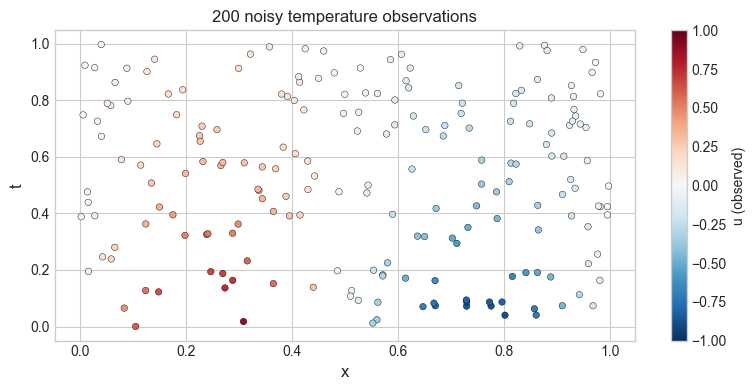

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(x_obs_np, t_obs_np, c=u_obs_np, cmap="RdBu_r", s=22,
                edgecolor="black", linewidth=0.3, vmin=-1, vmax=1)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("t", fontsize=12)
ax.set_title(f"{N_OBS} noisy temperature observations", fontsize=12)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("u (observed)")
fig.tight_layout()
plt.show()

## 4  Build the PINN — and Make $\alpha$ Trainable

Two things go into the optimizer:

1. The neural network $u_\theta(x, t)$ — a small Fourier-feature MLP, the architecture that won the Burgers shootout in notebook 02.
2. **`alpha` as an `nn.Parameter`.** That single line is what turns a forward solver into an inverse solver. The optimizer will compute gradients with respect to $\alpha$ alongside the network weights and update both each step.

In [4]:
from pinnrl.config import ModelConfig
from pinnrl.neural_networks import PINNModel

class _Cfg:
    """Minimal wrapper PINNModel expects."""
    def __init__(self, model_cfg, dev):
        self.model = model_cfg
        self.device = dev

model_cfg = ModelConfig(
    input_dim=2, hidden_dim=64, output_dim=1, num_layers=3,
    activation="tanh", architecture="fourier",
)
model_cfg.device = device
model_cfg.mapping_size = 32
model_cfg.scale = 4.0

model = PINNModel(_Cfg(model_cfg, device), device=device).to(device)

# The parameter we want to recover
alpha = torch.nn.Parameter(torch.tensor(INITIAL_GUESS, device=device))

n_net = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Network parameters : {n_net:,}")
print(f"Physics parameters : 1   (alpha)")
print(f"alpha is in optimizer: {alpha.requires_grad}")

Network parameters : 8,385
Physics parameters : 1   (alpha)
alpha is in optimizer: True


## 5  The Three-Component Loss

| Component | Equation | Enforces |
|-----------|----------|----------|
| **Data**    | $\mathcal{L}_{\text{data}} = \frac{1}{N}\sum (u_\theta(x_i, t_i) - u_i^{\text{obs}})^2$ | The network agrees with the measurements |
| **Residual** | $\mathcal{L}_{\text{pde}} = \frac{1}{N}\sum (u_t - \alpha\, u_{xx})^2$  | The network obeys *some* heat equation, with $\alpha$ free |
| **Initial**  | $\mathcal{L}_{\text{ic}} = \frac{1}{N}\sum (u_\theta(x, 0) - \sin(2\pi x))^2$ | The network respects the known initial state |

The data loss tells $\alpha$ what value makes the observations consistent. The residual loss tells the *network* to behave like a physical solution. They cooperate.

## 6  Train

In [5]:
N_EPOCHS = 1500
N_COLL   = 256
LR       = 5e-3
W_RES, W_DATA, W_IC = 1.0, 50.0, 10.0

# Initial-condition reference grid (re-used every step)
x_ic_np      = np.linspace(X_MIN, X_MAX, 100, dtype=np.float32).reshape(-1, 1)
x_ic         = torch.tensor(x_ic_np, device=device)
t_ic         = torch.zeros_like(x_ic)
u_ic_target  = torch.tensor(np.sin(2 * np.pi * x_ic_np), device=device)

# alpha goes into the optimizer alongside the network weights
optimizer = torch.optim.Adam(
    list(model.parameters()) + [alpha],
    lr=LR,
)

alpha_hist, data_hist, res_hist, ic_hist, total_hist = [], [], [], [], []

print(f"{'Epoch':>6}  {'alpha':>8}  {'data':>10}  {'residual':>10}  {'initial':>10}")
print("-" * 52)

t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    optimizer.zero_grad(set_to_none=True)

    # Random collocation points (where we enforce the residual)
    x_c = (torch.rand(N_COLL, 1, device=device) * (X_MAX - X_MIN) + X_MIN).requires_grad_(True)
    t_c = (torch.rand(N_COLL, 1, device=device) * (T_MAX - T_MIN) + T_MIN).requires_grad_(True)

    # PDE residual: u_t - alpha * u_xx
    u_c  = model(torch.cat([x_c, t_c], dim=1))
    u_t  = torch.autograd.grad(u_c,  t_c, torch.ones_like(u_c),  create_graph=True)[0]
    u_x  = torch.autograd.grad(u_c,  x_c, torch.ones_like(u_c),  create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,  x_c, torch.ones_like(u_x),  create_graph=True)[0]
    L_res  = torch.mean((u_t - alpha * u_xx) ** 2)

    # Data fit
    u_pred_obs = model(torch.cat([x_obs, t_obs], dim=1))
    L_data = torch.mean((u_pred_obs - u_obs) ** 2)

    # Initial condition
    u_pred_ic = model(torch.cat([x_ic, t_ic], dim=1))
    L_ic = torch.mean((u_pred_ic - u_ic_target) ** 2)

    L = W_RES * L_res + W_DATA * L_data + W_IC * L_ic
    L.backward()
    optimizer.step()

    alpha_hist.append(alpha.item())
    data_hist.append(L_data.item())
    res_hist.append(L_res.item())
    ic_hist.append(L_ic.item())
    total_hist.append(L.item())

    if epoch == 1 or epoch % 250 == 0:
        print(f"{epoch:>6}  {alpha.item():>8.5f}  {L_data.item():>10.3e}  "
              f"{L_res.item():>10.3e}  {L_ic.item():>10.3e}")

elapsed = time.time() - t0
print("-" * 52)
print(f"Trained in {elapsed:.1f}s")
print(f"\nTRUE alpha       : {TRUE_ALPHA}")
print(f"Recovered alpha  : {alpha.item():.5f}")
print(f"Relative error   : {abs(alpha.item() - TRUE_ALPHA) / TRUE_ALPHA * 100:.2f}%")

 Epoch     alpha        data    residual     initial
----------------------------------------------------
     1   0.49500   1.325e-01   3.946e+00   5.606e-01


   250   0.05008   3.146e-05   8.520e-04   1.300e-05


   500   0.05000   3.477e-05   3.530e-04   1.312e-05


   750   0.05001   2.327e-05   1.888e-04   1.913e-06


  1000   0.04989   2.290e-05   1.398e-04   1.396e-06


  1250   0.04998   2.225e-05   3.011e-04   1.936e-06


  1500   0.04997   9.816e-04   5.506e-04   6.320e-04
----------------------------------------------------
Trained in 4.4s

TRUE alpha       : 0.05
Recovered alpha  : 0.04997
Relative error   : 0.06%


## 7  $\alpha$ Convergence — the Money Plot

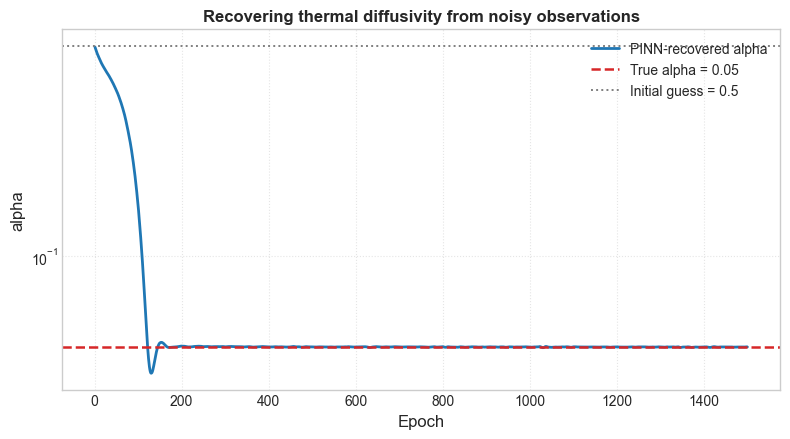

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(range(1, N_EPOCHS + 1), alpha_hist, lw=2.0, color="#1f77b4",
        label="PINN-recovered alpha")
ax.axhline(TRUE_ALPHA, ls="--", lw=1.8, color="#d62728",
           label=f"True alpha = {TRUE_ALPHA}")
ax.axhline(INITIAL_GUESS, ls=":", lw=1.4, color="#7f7f7f",
           label=f"Initial guess = {INITIAL_GUESS}")

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("alpha", fontsize=12)
ax.set_title("Recovering thermal diffusivity from noisy observations",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.set_yscale("log")
ax.grid(True, ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

## 8  Reconstructed Solution at $t = 0.5$

Compare three things:

- the analytical solution at the *true* $\alpha$,
- the PINN's predicted solution after training (at the *recovered* $\alpha$),
- the noisy observations within a small time band around $t=0.5$.

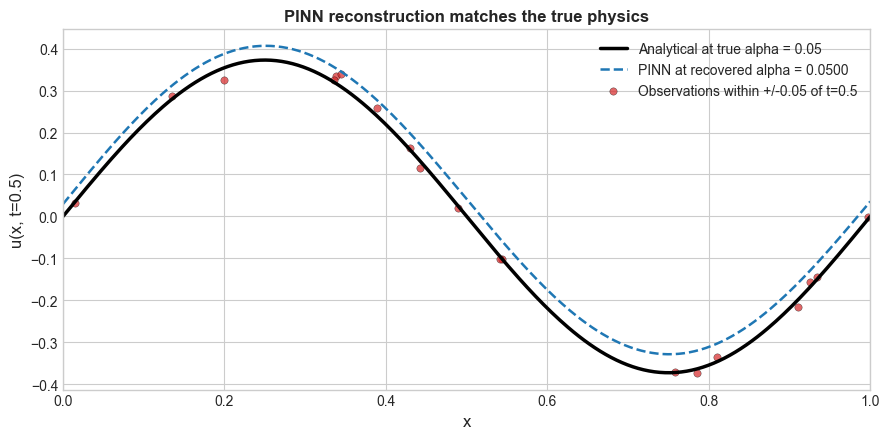

In [7]:
T_SNAP = 0.5
N_PLOT = 300

x_plot_np = np.linspace(X_MIN, X_MAX, N_PLOT, dtype=np.float32)
x_plot    = torch.tensor(x_plot_np.reshape(-1, 1), device=device)
t_plot    = torch.full_like(x_plot, T_SNAP)

model.eval()
with torch.no_grad():
    u_pinn = model(torch.cat([x_plot, t_plot], dim=1)).cpu().numpy().ravel()

u_true_at_snap = analytical_u(x_plot_np, T_SNAP, TRUE_ALPHA)

# Observations near t=T_SNAP
band = 0.05
near_mask = np.abs(t_obs_np.ravel() - T_SNAP) < band
x_obs_near = x_obs_np[near_mask].ravel()
u_obs_near = u_obs_np[near_mask].ravel()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_plot_np, u_true_at_snap, lw=2.5, color="black",
        label=f"Analytical at true alpha = {TRUE_ALPHA}")
ax.plot(x_plot_np, u_pinn, lw=1.8, ls="--", color="#1f77b4",
        label=f"PINN at recovered alpha = {alpha.item():.4f}")
ax.scatter(x_obs_near, u_obs_near, s=28, color="#d62728", alpha=0.7,
           edgecolor="black", linewidth=0.3,
           label=f"Observations within +/-{band:.2f} of t={T_SNAP}")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel(f"u(x, t={T_SNAP})", fontsize=12)
ax.set_title("PINN reconstruction matches the true physics",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
ax.set_xlim(X_MIN, X_MAX)
fig.tight_layout()
plt.show()

## 9  Loss Components Over Training

Watch the data and residual losses fall together — that's the cooperation between *fitting the data* and *being a physical solution*.

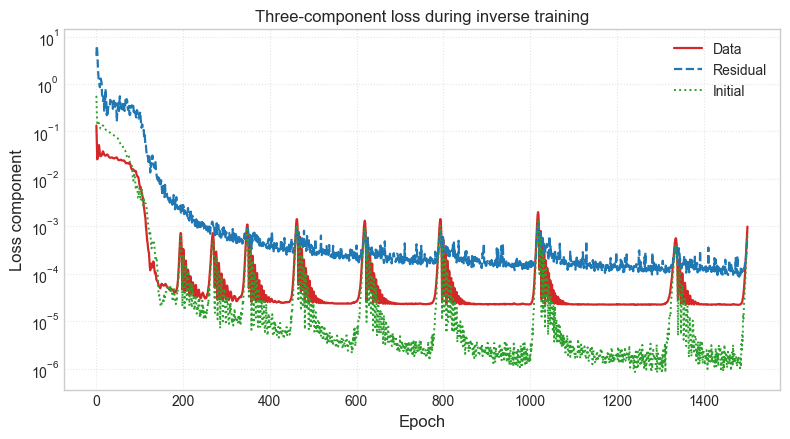

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
epochs = range(1, N_EPOCHS + 1)
ax.semilogy(epochs, data_hist, lw=1.6, label="Data",     color="#d62728")
ax.semilogy(epochs, res_hist,  lw=1.6, label="Residual", color="#1f77b4", ls="--")
ax.semilogy(epochs, ic_hist,   lw=1.4, label="Initial",  color="#2ca02c", ls=":")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss component", fontsize=12)
ax.set_title("Three-component loss during inverse training", fontsize=12)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.grid(True, ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

## 10  Production Path in `pinnrl`

We wrote the loss by hand here because it makes the mechanism obvious. For non-toy problems, `pinnrl` exposes the same setup through the trainer API and CLI, so you do not have to re-derive the residual every time you swap a PDE.

Equivalent of this notebook from the command line:

```bash
pinnrl-train --pde "Heat Equation" --arch fourier \
    --mode inverse --identify alpha --initial-guess alpha=0.5 \
    --obs-points 200 --obs-noise 0.005 --epochs 1500
```

The trainer will:

- register `alpha` as an `nn.Parameter` on the PDE,
- generate noisy observations from the analytical solution at the true value,
- attach a data-fitting loss to the existing residual + IC + BC objective,
- log the recovered parameter alongside the network's training metrics.

Bringing your own observations is just a `pde.observation_data = {"x": ..., "t": ..., "u": ...}` assignment — the trainer never knows the difference between synthetic noise and a real sensor file.

## 11  Save Key Plots

In [9]:
IMAGES_DIR = os.path.join(os.getcwd(), "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

# 1. alpha convergence (lead image)
fig_a, ax_a = plt.subplots(figsize=(8, 4.5))
ax_a.plot(range(1, N_EPOCHS + 1), alpha_hist, lw=2.0, color="#1f77b4",
          label="PINN-recovered alpha")
ax_a.axhline(TRUE_ALPHA, ls="--", lw=1.8, color="#d62728",
             label=f"True alpha = {TRUE_ALPHA}")
ax_a.axhline(INITIAL_GUESS, ls=":", lw=1.4, color="#7f7f7f",
             label=f"Initial guess = {INITIAL_GUESS}")
ax_a.set_xlabel("Epoch", fontsize=12)
ax_a.set_ylabel("alpha", fontsize=12)
ax_a.set_title("Recovering thermal diffusivity from noisy observations",
               fontsize=12, fontweight="bold")
ax_a.legend(loc="upper right", frameon=False, fontsize=10)
ax_a.set_yscale("log")
ax_a.grid(True, ls=":", alpha=0.5)
fig_a.tight_layout()
alpha_path = os.path.join(IMAGES_DIR, "05_alpha_convergence.png")
fig_a.savefig(alpha_path, dpi=200, bbox_inches="tight")
plt.close(fig_a)
print(f"Alpha convergence -> {alpha_path}")

# 2. solution overlay
fig_s, ax_s = plt.subplots(figsize=(9, 4.5))
ax_s.plot(x_plot_np, u_true_at_snap, lw=2.5, color="black",
          label=f"Analytical at true alpha = {TRUE_ALPHA}")
ax_s.plot(x_plot_np, u_pinn, lw=1.8, ls="--", color="#1f77b4",
          label=f"PINN at recovered alpha = {alpha.item():.4f}")
ax_s.scatter(x_obs_near, u_obs_near, s=28, color="#d62728", alpha=0.7,
             edgecolor="black", linewidth=0.3,
             label=f"Observations near t={T_SNAP}")
ax_s.set_xlabel("x", fontsize=12)
ax_s.set_ylabel(f"u(x, t={T_SNAP})", fontsize=12)
ax_s.set_title("PINN reconstruction matches the true physics",
               fontsize=12, fontweight="bold")
ax_s.legend(fontsize=10, loc="upper right")
ax_s.set_xlim(X_MIN, X_MAX)
fig_s.tight_layout()
sol_path = os.path.join(IMAGES_DIR, "05_inverse_solution.png")
fig_s.savefig(sol_path, dpi=200, bbox_inches="tight")
plt.close(fig_s)
print(f"Solution overlay  -> {sol_path}")

Alpha convergence -> /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/05_alpha_convergence.png
Solution overlay  -> /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/05_inverse_solution.png


## 12  What to Try Next

- **Identify two parameters at once.** The Burgers equation has both viscosity $\nu$ and an unknown forcing amplitude. Add both to `--identify`.
- **Sparser / noisier data.** Drop `N_OBS` to 50 and triple `NOISE_STD`. PINNs degrade gracefully and you can compute uncertainty bands by training with multiple seeds.
- **Real measurements.** Replace the synthetic block with a `(x, t, u)` CSV from a thermal-imaging dataset. The training loop does not change.
- **Wave-speed inversion.** Same recipe with the wave equation: $u_{tt} = c^2 u_{xx}$, `--identify c`. Useful for seismic and acoustic problems.

---

**Previous notebook:** [`04_well_dataset_quickstart.ipynb`](04_well_dataset_quickstart.ipynb)